Practice AASTHA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv('IMDB Dataset (1).csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
df.isna().sum()

,0
review,0
sentiment,0


In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [14]:
X = df['review'].values
y = df['sentiment']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [16]:
VOCAB_SIZE = 10000 #top 10000 words
MAX_LEN=200 #max length per review

In [17]:
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer

#reads texxt , builds vocabulary, converts words to numbers
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
#assign an integer index to each word based on frequency
tokenizer.fit_on_texts(X_train)

#convert the training text reviews to sequence of integers
#each word in a review is replaced by its corresponding index from the tokenizer's vocabulary
X_train_seq = tokenizer.texts_to_sequences(X_train)

#convert test text reviews
X_test_seq = tokenizer.texts_to_sequences(X_test)


In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Pad the training sequences so that all sequences are of equal length
# - maxlen: maximum length of sequences after padding/truncating
# - padding="post": pads zeros at the end of each sequence
# - truncating="post": truncates extra words from the end if a sequence is too long

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

model = Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=16, input_length=MAX_LEN),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# # ----- 3. Train -----
# history = model.fit(
#     X_train, y_train,
#     epochs=10,
#     batch_size=512,
#     validation_split=0.2,
#     verbose=1
# )

# # ----- 4. Evaluate -----
# loss, acc = model.evaluate(X_test, y_test, verbose=0)
# print(f"\nTest Accuracy: {acc*100:.2f}%")

model.fit(X_train_pad, y_train, epochs=10, batch_size=512, validation_split=0.2,verbose=1)

loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nTest accuracy: {acc*100:.2f}%")
print(f"Test loss: {loss*100:.2f}%")

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.6230 - loss: 0.6825 - val_accuracy: 0.7034 - val_loss: 0.6635
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.7358 - loss: 0.6272 - val_accuracy: 0.7780 - val_loss: 0.5835
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8016 - loss: 0.5275 - val_accuracy: 0.8220 - val_loss: 0.4799
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8373 - loss: 0.4326 - val_accuracy: 0.8294 - val_loss: 0.4130
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8553 - loss: 0.3723 - val_accuracy: 0.8508 - val_loss: 0.3709
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8692 - loss: 0.3348 - val_accuracy: 0.8571 - val_loss: 0.3466
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8800 - loss: 0.3079 - val_accuracy: 0.8644 - val_loss: 0.3312
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8874 - loss: 0.2893 - val_accuracy: 0.8680 - v

In [22]:
y_pred_prob = model.predict(X_test_pad)
y_prob = (y_pred_prob > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


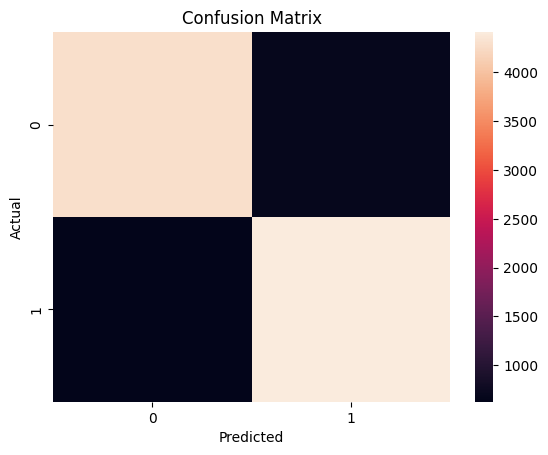

In [23]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix, classification_report

# # confusion matrix
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=['negative', 'positive'],
#             yticklabels=['negative', 'positive'])
# plt.xlabel('predicted')
# plt.ylabel('actual')
# plt.title('confusion matrix')
# plt.show()
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


cm = confusion_matrix(y_test, y_prob)
sns.heatmap(cm)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [24]:

# classification report
print('Classification Report:')
print(classification_report(y_test, y_prob, target_names=['negative', 'positive']))

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.86      0.87      4961
    positive       0.87      0.88      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

